# Установка библиотек

Устанавливаем набор библиотек для:

- загрузки и работы с моделью (transformers)

- QLoRA / PEFT (peft, bitsandbytes)

- удобного SFT-обучения (trl)

- ускоренной загрузки/обучения в 4-bit (unsloth)

- работы с датасетами (datasets)

In [1]:
!pip -q install -U unsloth trl datasets accelerate bitsandbytes transformers sentencepiece peft pandas tqdm

Проверяем ГПУ в collab

In [3]:
!nvidia-smi

Sat Feb 14 18:59:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   32C    P0            117W /  700W |     527MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [4]:
# Полная очистка GPU/VRAM (после удаления больших моделей/тренера)
import gc, torch

# 1) Удаляем возможные крупные объекты (если существуют)
for name in ["trainer", "model", "base_model", "ft_model", "merged", "base", "m2"]:
    if name in globals():
        del globals()[name]

# 2) Сборщик мусора Python
gc.collect()

# 3) Очистка кэшей CUDA
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# 4) (Опционально) очистка кешей компиляции Torch 2.x (если есть)
try:
    torch._dynamo.reset()
except Exception:
    pass

print("GPU cleanup done.")
if torch.cuda.is_available():
    print("VRAM allocated (GB):", round(torch.cuda.memory_allocated()/1024**3, 3))
    print("VRAM reserved  (GB):", round(torch.cuda.memory_reserved()/1024**3, 3))


GPU cleanup done.
VRAM allocated (GB): 0.0
VRAM reserved  (GB): 0.0


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"


# Задача

**Стилизатор под русскую классику на корпусе RusLit.**
- Дообучить инструктивную LLM так, чтобы она лучше генерировала текст в стиле русской классики. Для проверки:


- Вход (instruction): "Продолжи художественный текст (сохраняя стиль…)" + начало фрагмента
- Выход (target): продолжение фрагмента

**Гипотеза - Fine-tuning через LoRA/QLoRA заметно меняет стиль и лексику, эффект видно "до/после".**



# Датасет

Датасет: RusLit — Russian literature (txt, UTF-8)
https://github.com/d0rj/RusLit.git

Описание датасета:
Коллекция русской литературы в формате .txt (всё в UTF-8). Для каждого автора также есть csv-файл с информацией (например, год написания произведения).
Датасет создавался для задачи определения авторства, но его можно использовать и для других целей.

Важно: данные не обработаны.

**Почему RusLit подходит для стилизации:**

реальные художественные тексты = богатая лексика и синтаксис.

## Загрузка RusLit

In [3]:
import os, glob, pandas as pd

!rm -rf RusLit
!git clone --depth 1 https://github.com/d0rj/RusLit.git

print("Files:", os.listdir("RusLit")[:20])

txt_files = glob.glob("RusLit/**/*.txt", recursive=True)
print("TXT count:", len(txt_files))
print("Example:", txt_files[:5])


Cloning into 'RusLit'...
remote: Enumerating objects: 411, done.
remote: Counting objects: 100% (411/411), done.
remote: Compressing objects: 100% (410/410), done.
remote: Total 411 (delta 0), reused 393 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (411/411), 19.23 MiB | 19.28 MiB/s, done.
Files: ['poems', 'Tolstoy_and_Chekhov_1901.jpg', '.git', 'prose', 'publicism', 'README.md']
TXT count: 373
Example: ['RusLit/poems/Nekrasov/Мороз, красный нос.txt', 'RusLit/poems/Nekrasov/Вчерашний день, часу в шестом....txt', 'RusLit/poems/Nekrasov/Элегия.txt', 'RusLit/poems/Nekrasov/Крестьянские дети.txt', 'RusLit/poems/Nekrasov/Кому на Руси жить хорошо.txt']


In [4]:
import random

def read_text(path, max_chars=4000):
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        s = f.read()
    s = s.replace("\r\n", "\n").strip()
    return s[:max_chars]

random.seed(42)
sample_paths = random.sample(txt_files, k=min(5, len(txt_files)))

for p in sample_paths:
    print("="*120)
    print("FILE:", p)
    print(read_text(p, 50))


FILE: RusLit/prose/Herzen/Доктор Крупов.txt
Александр Иванович Герцен
  
  
   ДОКТОР КРУПОВ
 
FILE: RusLit/poems/Pushkin/Руслан и Людмила.txt
,   ,
     ,   
       ,
        ,
        ,
     
FILE: RusLit/poems/Nekrasov/Поэт и гражданин.txt
Николай Некрасов
ПОЭТ И ГРАЖДАНИН
Гражданин (входи
FILE: RusLit/prose/Chekhov/Беглец.txt
Антон Чехов
БЕГЛЕЦ
Это была длинная процедура. Сна
FILE: RusLit/prose/Chekhov/Лошадиная фамилия.txt
Антон Чехов
ЛОШАДИНАЯ ФАМИЛИЯ
У отставного генерал


**Вывод - нужна предобработка и очистка**

In [5]:
import re
from tqdm import tqdm

RE_META_BRACKETS = re.compile(r"\[[^\]]{10,}\]")                 # длинные вставки в [..]
RE_RULE_LINE     = re.compile(r"^[=\-_*]{8,}\s*$", re.M)         # ======= / ----- / *****
RE_PUNCT_LINE    = re.compile(r"^\s*[\W_]+\s*$", re.M)           # строка из одной пунктуации/символов
RE_SPACES        = re.compile(r"[ \t]+")

def clean_text(text: str) -> str:
    text = text.replace("\r\n", "\n")
    text = RE_RULE_LINE.sub("\n", text)      # убрать линии разделителей
    text = RE_PUNCT_LINE.sub("\n", text)     # убрать строки из одной пунктуации
    text = RE_META_BRACKETS.sub(" ", text)   # убрать длинные [примечания]
    text = re.sub(r"\n{3,}", "\n\n", text)   # нормализовать пустые строки
    return text.strip()

def smart_cut(s: str, pos: int, min_cont: int):
    # режем по "границе": пробел или знак препинания
    right = s.find(" ", pos)
    if 0 <= right <= len(s) - min_cont:
        return right
    left = s.rfind(" ", 0, pos)
    if left > 0:
        return left
    return pos

def make_pairs(text: str, min_par=300, min_prefix=160, min_cont=120):
    text = clean_text(text)
    pairs = []

    for par in (p.strip() for p in text.split("\n\n")):
        if len(par) < min_par:
            continue

        par = RE_SPACES.sub(" ", par)
        par = re.sub(r"\s+", " ", par).strip()
        if len(par) < min_prefix + min_cont:
            continue

        # базовая позиция разреза ~35% абзаца
        cut = max(min_prefix, int(len(par) * 0.35))
        cut = min(cut, len(par) - min_cont)
        cut = smart_cut(par, cut, min_cont)

        prefix, cont = par[:cut].strip(), par[cut:].strip()
        if len(prefix) >= min_prefix and len(cont) >= min_cont:
            pairs.append((prefix, cont))

    return pairs


MAX_FILES = 200
MAX_SAMPLES = 8000

samples = []
for p in tqdm(txt_files[:MAX_FILES]):
    with open(p, "r", encoding="utf-8", errors="ignore") as f:
        samples.extend(make_pairs(f.read()))
    if len(samples) >= MAX_SAMPLES:
        samples = samples[:MAX_SAMPLES]
        break

print("Collected samples:", len(samples))
print("PREFIX:", samples[0][0][-250:], "...")
print("CONT  :", samples[0][1][:250], "...")


100%|██████████| 200/200 [00:01<00:00, 164.71it/s]

Collected samples: 1566
PREFIX:  ли тот дар, Что, бывало, дружил меня с нею? Но не брат еще людям поэт, И тернист его путь, и непрочен, Я умел не бояться клевет, Не был ими я сам озабочен; Но я знал, чье во мраке ночном Надрывалося сердце с печали И на чью они грудь упадали свинцом ...
CONT  : И кому они жизнь отравляли. И пускай они мимо прошли, Надо мною ходившие грозы, Знаю я, чьи молитвы и слезы Роковую стрелу отвели... Да и время ушло, — я устал... Пусть я не был бойцом без упрека, Но я силы в себе сознавал, Я во многое верил глубоко, ...


## Создаём HF Dataset в чат-формате (для Qwen Instruct)

Чтобы обучать инструктивную модель, превращаем пары в messages:

system: "пишешь по-русски художественной прозой…"

user: "Продолжи текст…" + prefix

assistant: continuation

Далее делим на train/eval.

In [8]:
# OLD!!!

from datasets import Dataset

def to_chat_record(prefix, cont):
    return {
        "messages": [
            {"role": "system", "content": "Ты пишешь на русском языке художественной прозой в стиле русской классики."},
            {"role": "user", "content": "Продолжи художественный текст (сохраняя стиль, темп и лексику):\n\n" + prefix},
            {"role": "assistant", "content": cont},
        ]
    }

data = [to_chat_record(pfx, cont) for pfx, cont in samples]

ds = Dataset.from_list(data).shuffle(seed=42)

split = ds.train_test_split(test_size=0.1, seed=42)  # 10% -> ~150-170 eval
train_ds = split["train"]
eval_ds  = split["test"]

print(train_ds[0])
print("Train:", len(train_ds), "Eval:", len(eval_ds))


{'messages': [{'content': 'Ты пишешь на русском языке художественной прозой в стиле русской классики.', 'role': 'system'}, {'content': 'Продолжи художественный текст (сохраняя стиль, темп и лексику):\n\nВлачим мы дни свои уныло, Волнений далеки чужих; От нас сокрыто, нам не мило, Что вечно радует других... Влачим мы дни свои без веры, Судьба устала нас карать...', 'role': 'user'}, {'content': 'И наша жизнь тяжка без меры, И тяжко будет умирать... Так век, умчавшись беспощадно, Встречая новый строй веков, Бросает им загадкой хладной Живых, безумных мертвецов...', 'role': 'assistant'}]}
Train: 1409 Eval: 157


# Выбор модели и стратегия обучения (QLoRA)

**Qwen2.5-7B-Instruct - обучаем через QLoRA:**

- модель грузится в 4-bit

- обучаются только LoRA-адаптеры

- это экономит память и ускоряет обучение в Colab

**Цель обучения:**
улучшить способность модели продолжать фрагменты в классическом стиле.

## Загрузка Qwen2.5-7B-Instruct 4-bit через Unsloth

**FastLanguageModel.from_pretrained(...)**
Загружаем базовую модель Qwen2.5-7B-Instruct через Unsloth.

- **load_in_4bit=True** — модель загружается в 4-битном виде (квантование).

**max_seq_length=2048** — максимальная длина контекста (в токенах), с которой будем тренироваться/генерировать.

**Unsloth** оборачивает модель и ускоряет обучение (оптимизации под PEFT/QLoRA), это быстрее и стабильнее, чем transformers на тех же настройках.

**FastLanguageModel.get_peft_model(...)**

- Добавляем LoRA-адаптеры (маленькие обучаемые матрицы), которые подмешиваются в ключевые линейные слои трансформера.

- Базовые веса модели остаются замороженными, а обучаются только LoRA-параметры = parameter-efficient fine-tuning (PEFT).

**Параметры LoRA**

**r = 16. Rank (ранг) LoRA** — размер адаптера.
Чем выше r, тем больше обучаемых параметров и тем сильнее модель может адаптироваться, но тем больше память/время.
16 — хороший баланс для стилизации/доменных задач.

- target_modules = [...]
Список слоев, куда вставляем LoRA:

**q_proj, k_proj, v_proj, o_proj** — проекции внимания (attention)

**gate_proj, up_proj, down_proj** — проекции MLP-блока (feed-forward)


Это самые влияющие места модели: attention отвечает за связи в тексте, MLP — за преобразование представлений.
Включая оба набора, мы обычно получаем более заметный эффект на стиле.

**lora_alpha = 16**.
Масштабирование вклада LoRA.
Часто ставят равным r или близко к нему.

**lora_dropout = 0.0**
Dropout внутри LoRA.
Для SFT на тексте можно ставить 0.0.
Если начнется переобучение на маленьком датасете — можно поднять до 0.05.

**bias = "none"**
Не обучаем bias-параметры в слоях модели — только LoRA-матрицы.
Это экономит память и обычно достаточно для адаптации.

**use_gradient_checkpointing = "unsloth"**
Включает gradient checkpointing (экономия VRAM за счёт перерасчёта некоторых активаций на backward).
Это позволяет держать больший контекст / batch в той же памяти.
Unsloth делает это оптимизированно.

**random_state = 42**
Фиксируем seed, чтобы результаты были более воспроизводимыми.

In [11]:
from unsloth import FastLanguageModel
import torch

model_name = "Qwen/Qwen2.5-7B-Instruct"

max_seq_length = 2048

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = model_name,
    max_seq_length = max_seq_length,
    dtype = None,            # авто
    load_in_4bit = True,     # QLoRA
)

model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout=0.05,
    bias = "none",
    use_gradient_checkpointing="unsloth",
    random_state = 42,
)

print("Loaded. CUDA:", torch.cuda.is_available())


==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded. CUDA: True


In [12]:
from datasets import Dataset

SYSTEM = "Ты пишешь в стиле русской классики."

def to_record(prefix, cont):
    return {"prefix": prefix, "cont": cont}

raw = Dataset.from_list([to_record(pfx, cont) for pfx, cont in samples]).shuffle(seed=42)

# важно для паддинга
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

max_seq_length = 2048

def preprocess(batch):
    input_ids_list, labels_list, attn_list = [], [], []

    for prefix, cont in zip(batch["prefix"], batch["cont"]):
        # prompt = system+user + generation prompt (шапка assistant) -> МАСКИРУЕМ
        prompt_messages = [
            {"role": "system", "content": SYSTEM},
            {"role": "user", "content": "Продолжи художественный текст (сохраняя стиль, темп и лексику):\n\n" + prefix},
        ]
        prompt_text = tokenizer.apply_chat_template(
            prompt_messages,
            tokenize=False,
            add_generation_prompt=True,   # добавит начало assistant-ответа
        )

        prompt_ids = tokenizer(prompt_text, add_special_tokens=False)["input_ids"]

        # completion = чистый текст ассистента + eos -> НЕ маскируем
        completion_ids = tokenizer(cont, add_special_tokens=False)["input_ids"]
        if tokenizer.eos_token_id is not None:
            completion_ids = completion_ids + [tokenizer.eos_token_id]

        input_ids = prompt_ids + completion_ids
        labels    = [-100] * len(prompt_ids) + completion_ids
        attn      = [1] * len(input_ids)

        # truncate (с сохранением выравнивания)
        input_ids = input_ids[:max_seq_length]
        labels    = labels[:max_seq_length]
        attn      = attn[:max_seq_length]

        input_ids_list.append(input_ids)
        labels_list.append(labels)
        attn_list.append(attn)

    return {"input_ids": input_ids_list, "labels": labels_list, "attention_mask": attn_list}

tok = raw.map(preprocess, batched=True, remove_columns=raw.column_names)

tok = tok.filter(lambda x: any(l != -100 for l in x["labels"]))

split = tok.train_test_split(test_size=0.1, seed=42)
train_ds, eval_ds = split["train"], split["test"]

print(train_ds[0].keys())
print("Train:", len(train_ds), "Eval:", len(eval_ds))


Map:   0%|          | 0/1566 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1566 [00:00<?, ? examples/s]

dict_keys(['input_ids', 'labels', 'attention_mask'])
Train: 1294 Eval: 144



**Итог**

После выполнения ячейки у нас есть:
- квантованная базовая модель Qwen (4-bit)
- поверх неё подключены LoRA-адаптеры (обучаемые параметры)


Дальше в тренере мы будем обучать только эти адаптеры, чтобы модель начала лучше писать в стиле русской классики.

# Fine-tuning через SFTTrainer (TRL)


Запускаем **supervised fine-tuning (SFT)** — дообучение модели на парах инструкция → правильный ответ.


Данные уже подготовлены в chat-формате messages (system/user/assistant), поэтому SFT отлично подходит: модель учится генерировать продолжение и соблюдать нужный стиль.

**SFTTrainer(...)**

- model=model — базовая LLM с подключёнными LoRA-адаптерами (обучаться будут они).

- tokenizer=tokenizer — токенизатор для преобразования текста в токены модели.

- train_dataset=train_ds — обучающая выборка.

- eval_dataset=eval_ds — валидационная выборка (для контроля качества во время обучения).

- dataset_text_field="messages" — поле датасета, где лежит чат-структура (system/user/assistant). SFTTrainer умеет это поле превращать в текст через chat-template.

- max_seq_length=max_seq_length — максимальная длина последовательности (в токенах), на которую нарезаются/упаковываются примеры.

- packing=True — упаковка нескольких коротких примеров в одну длинную последовательность до max_seq_length = меньше паддинга, быстрее обучение.

**TrainingArguments(...)**

- output_dir="qwen_ruslit_lora" — папка, куда сохраняются чекпойнты и логи.

- per_device_train_batch_size — batch size на одну GPU (сколько примеров одновременно).

- gradient_accumulation_steps=4 — накопление градиента

- learning_rate=2e-4 (меняем) — скорость обучения

- num_train_epochs — сколько раз пройти весь train-набор

- logging_steps=25 — как часто писать логи (loss и т.п.).

- save_steps=200 — как часто сохранять чекпойнт.

- evaluation_strategy="steps" — оценивать на eval_dataset не по эпохам, а по шагам.

- eval_steps=200 — частота оценки на валидации (раз в 200 шагов).

- warmup_steps=50 — разгон learning rate в начале, чтобы обучение стартовало стабильнее.

- fp16 = not torch.cuda.is_bf16_supported() — если bf16 не поддерживается, используем fp16.

- bf16 = torch.cuda.is_bf16_supported() — если GPU поддерживает bf16, используем bf16 (обычно стабильнее).

- optim="adamw_8bit" — 8-битный AdamW (экономит память, хорошо для Colab/QLoRA).

- weight_decay=0.0 — L2-регуляризация (для LoRA часто ставят 0 или небольшое значение).

- lr_scheduler_type="cosine" — расписание learning rate: плавное снижение по косинусу.

- report_to="none" — не отправлять логи в внешние трекеры (W&B, MLflow и т.д.).

In [13]:
import torch

class PadOnlyCollator:
    def __init__(self, tokenizer):
        self.pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else tokenizer.eos_token_id

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)

        def pad(seq, pad_value):
            return seq + [pad_value] * (max_len - len(seq))

        input_ids_batch = []
        attn_batch = []
        labels_batch = []

        for f in features:
            ids = f["input_ids"]
            labels = f["labels"]

            # если attention_mask отсутствует — делаем сами
            attn = f.get("attention_mask", None)
            if attn is None:
                attn = [1] * len(ids)

            input_ids_batch.append(pad(ids, self.pad_id))
            attn_batch.append(pad(attn, 0))
            labels_batch.append(pad(labels, -100))

        return {
            "input_ids": torch.tensor(input_ids_batch, dtype=torch.long),
            "attention_mask": torch.tensor(attn_batch, dtype=torch.long),
            "labels": torch.tensor(labels_batch, dtype=torch.long),
        }

collator = PadOnlyCollator(tokenizer)


In [14]:
import torch
from trl import SFTTrainer
from transformers import TrainingArguments, EarlyStoppingCallback

args = TrainingArguments(
    output_dir="qwen_ruslit_lora",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    num_train_epochs=3,
    logging_steps=10,
    save_steps=25,

    eval_strategy="steps",
    eval_steps=25,

    warmup_steps=10,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    optim="adamw_8bit",
    weight_decay=0.0,
    lr_scheduler_type="cosine",
    report_to="none",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=5,
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collator,
    max_seq_length=max_seq_length,
    packing=False,
    args=args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)


In [15]:
train_result = trainer.train()

print("Training finished.")
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,294 | Num Epochs = 3 | Total steps = 486
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss,Validation Loss
25,2.142800,2.243174
50,2.206700,2.222491
75,2.205400,2.212613
100,2.087200,2.204520
125,2.036000,2.197783
150,2.086400,2.190331
175,2.007400,2.196848
200,2.024200,2.212639
225,1.940500,2.206718


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Training finished.
Best checkpoint: qwen_ruslit_lora/checkpoint-150
Best metric: 2.190330982208252


## Графики процесса обучения

In [16]:
metrics = train_result.metrics
trainer.save_metrics("train", metrics)
trainer.save_state()

print("Train done. Logged rows:", len(trainer.state.log_history))

Train done. Logged rows: 32


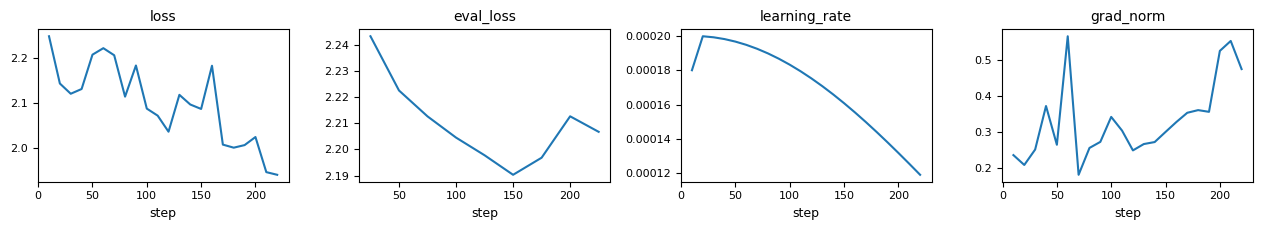

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

logs = pd.DataFrame(trainer.state.log_history)
if "step" not in logs.columns:
    logs["step"] = range(len(logs))

# оставим только нужные колонки (если есть)
cols = ["loss", "eval_loss", "learning_rate", "grad_norm"]
present = [c for c in cols if c in logs.columns]

# маленькие графики в один ряд (если 4 метрики) или в 2х2
k = len(present)
ncols = 4 if k >= 4 else k
nrows = (k + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3.2*ncols, 2.4*nrows), squeeze=False)

for ax, col in zip(axes.ravel(), present):
    d = logs[logs[col].notna()]
    ax.plot(d["step"], d[col])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("step", fontsize=9)
    ax.tick_params(axis="both", labelsize=8)

# спрятать лишние оси, если метрик меньше чем слотов
for ax in axes.ravel()[len(present):]:
    ax.axis("off")

plt.tight_layout()
plt.show()



**loss** — тренировочная ошибка (train loss) на батчах. В идеале в среднем снижается: модель лучше подгоняется под train-данные. Может прыгать из-за разных батчей/packing.

**eval_loss** — ошибка на валидации. Главный индикатор обобщения: если падает вместе с loss — хорошо; если loss падает, а eval_loss стоит/растёт — признак переобучения или шумной/маленькой валидации.

**learning_rate** — как меняется скорость обучения по расписанию (у тебя cosine + warmup): сначала растёт (warmup), потом плавно уменьшается. Это помогает стабильности и дошлифовке к концу.

**grad_norm** — норма градиента (насколько сильные обновления). Сильно большие пики могут означать нестабильность/слишком высокий LR; слишком маленькие значения — что обучение почти не двигается.

## Сохранение LoRA-адаптера

Сохраняем только LoRA-веса и токенайзер, чтобы потом легко подключать к базовой модели.

In [18]:
model.save_pretrained("qwen_ruslit_lora_adapter")
tokenizer.save_pretrained("qwen_ruslit_lora_adapter")
print("Saved to qwen_ruslit_lora_adapter")

Saved to qwen_ruslit_lora_adapter


# Генерация ДО/ПОСЛЕ

In [19]:
from unsloth import FastLanguageModel

# 1) Загружаем base и finetuned (как раньше)
base_model, base_tok = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)

ft_model, ft_tok = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)
ft_model.load_adapter("qwen_ruslit_lora_adapter")

==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Ускорение generate: включить inference mode Unsloth

In [20]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(base_model)
FastLanguageModel.for_inference(ft_model)
print("Unsloth inference mode enabled")


Unsloth inference mode enabled


In [21]:
import torch

def generate_chat(m, tok, user_text, system_text, gen_cfg, seed=42):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]

    enc = tok.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        return_dict=True,
    )

    input_ids = enc["input_ids"].to("cuda")
    attention_mask = enc["attention_mask"].to("cuda")

    with torch.no_grad():
        out = m.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pad_token_id=tok.eos_token_id,
            **gen_cfg
        )

    return tok.decode(out[0], skip_special_tokens=True)


In [22]:
import re
import pandas as pd

def only_assistant(text: str) -> str:
    m = re.search(r"(?:^|\n)\s*assistant\s*", text)
    if not m:
        m = re.search(r"(?:^|\n)\s*assistant\s*:\s*", text)
    if not m:
        return text.strip()

    idx = text.lower().rfind("assistant")
    out = text[idx+len("assistant"):].lstrip(" :\n\t")
    return out.strip()

system_text = (
    "Ты пишешь в стиле русской классики."
)

gen_cfg = dict(
    max_new_tokens=500,
    do_sample=True,
    temperature=0.5,
    top_p=0.9,
)

prompts = [
    "Опиши утро в зимнем городе так, чтобы было образно и спокойно.",
    "Напиши сцену: человек едет в поезде и вспоминает важный разговор.",
    "Объясни, почему люди ссорятся из-за пустяков, но сделай это художественно.",
    "Продолжи: «Он вошёл в комнату, и ему показалось, что воздух здесь тяжелее…»",
    "Напиши письмо другу, который сомневается в выборе пути, с мягкой моральной нотой.",
]

rows = []
for i, p in enumerate(prompts, start=1):
    print(f"\n{'='*90}\n[{i}/{len(prompts)}] PROMPT:\n{p}\n")

    before_raw = generate_chat(base_model, base_tok, p, system_text, gen_cfg, seed=1000+i)
    before = only_assistant(before_raw)
    print("[BASE] assistant-only preview:", before[:350].replace("\n", " "), "...\n")

    after_raw = generate_chat(ft_model, ft_tok, p, system_text, gen_cfg, seed=1000+i)
    after = only_assistant(after_raw)
    print("[FT] assistant-only preview:", after[:350].replace("\n", " "), "...\n")

    rows.append({"prompt": p, "before_base": before, "after_finetuned": after})

df = pd.DataFrame(rows)
df



[1/5] PROMPT:
Опиши утро в зимнем городе так, чтобы было образно и спокойно.

[BASE] assistant-only preview: В тишине зимнего утра, когда сонный мир еще не проснулся от холодного мороза, город лежит покрытым белым одеялом снега, словно засыпанный снежной пуховкой. Солнце только начинает подниматься над горизонтом, его первые лучи медленно пробиваются сквозь серое небо, создавая на крышах и улицах рисунки золотых и алых полос. Воздух наполнен свежестью и ч ...

[FT] assistant-only preview: Утро в зимнем городе. Проснись, птица, проснись! Ступай на крыльцо, воротись, крикни в окно: "Здравствуйте!" Взгляни в синее небо, - оно зовет тебя... Нет, не зовет, не зовет, - он молчит. Пора, пора, - и ты должна улететь. Солнце встало, солнце сияет. На небе голубом, - как ледяной туман, - Оно блестит, блестит... И снег на крыше, на деревьях, на  ...


[2/5] PROMPT:
Напиши сцену: человек едет в поезде и вспоминает важный разговор.

[BASE] assistant-only preview: В глубине ночи, когда мир был уedido

,prompt,before_base,after_finetuned
0,"Опиши утро в зимнем городе так, чтобы было обр...","В тишине зимнего утра, когда сонный мир еще не...","Утро в зимнем городе. Проснись, птица, проснис..."
1,Напиши сцену: человек едет в поезде и вспомина...,"В глубине ночи, когда мир был уedido мраком, и...","Его собеседник - неизвестный, но он точно знае..."
2,"Объясни, почему люди ссорятся из-за пустяков, ...",Вот попытка передать эту мысль в стиле русской...,"Но ведь это не пустяки, а самые серьезные вопр..."
3,"Продолжи: «Он вошёл в комнату, и ему показалос...","Он вошёл в комнату, и ему показалось, что возд...","— Марья Александровна! — начал он, но не догов..."
4,"Напиши письмо другу, который сомневается в выб...","Уважаемый друг,\n\nВаше сомнение в выборе пути...","У меня нет твоих умных и глубоких размышлений,..."


## Оценка результата

После дообучения на RusLit модель устойчиво сместилась в сторону художественной манеры: больше диалогов, риторики, повторов, драматического подтекста и сцены.

При этом вырос риск побочных эффектов:

- Снижение управляемости: модель иногда игнорирует тональность или жанровую рамку.

- Рост драматизации и морализаторства: чаще выбирает конфликт/оценку вместо спокойного описания/объяснения.

- Повторяемость.


**Адаптер хорошо подходит для классической стилизации и сцен, но для задач, где важно строго держать тон и точное следование запросу, может потребоваться дополнительная настройка decoding (temperature/top_p) или более строгий системный промпт.**

# Hugging Face

In [23]:
!pip -q install -U huggingface_hub

from huggingface_hub import notebook_login
notebook_login()  #HF token

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.3/553.3 kB 12.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.57.6 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.4.1 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.0 which is incompatible.


## Пуш адаптера в HF Hub

In [24]:
from huggingface_hub import HfApi

HF_USERNAME = "divisee"
REPO_NAME = "qwen2.5-7b-ruslit-classic-lora"
REPO_ID = f"{HF_USERNAME}/{REPO_NAME}"

# Создадим репозиторий (если уже есть — просто продолжим)
api = HfApi()
try:
    api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)
    print("Repo ready:", REPO_ID)
except Exception as e:
    print("Repo create warning:", e)

# Пушим LoRA адаптер + tokenizer
ft_model.push_to_hub(REPO_ID)
ft_tok.push_to_hub(REPO_ID)

print("Pushed adapter to:", REPO_ID)


Repo ready: divisee/qwen2.5-7b-ruslit-classic-lora


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          |  557kB /  149MB            

Saved model to https://huggingface.co/divisee/qwen2.5-7b-ruslit-classic-lora


README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpu8a8oo5d/tokenizer.json:   0%|          | 27.6kB / 11.4MB            

Pushed adapter to: divisee/qwen2.5-7b-ruslit-classic-lora


## Пример загрузки адаптера из HF

In [ ]:
from unsloth import FastLanguageModel

base, tok = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    max_seq_length=2048,
    load_in_4bit=True,
)

base.load_adapter("divisee/qwen2.5-7b-ruslit-classic-lora")
print("Loaded adapter from HF!")


In [30]:
from unsloth import FastLanguageModel
import torch

base_model = "Qwen/Qwen2.5-7B-Instruct"
adapter_model = "divisee/qwen2.5-7b-ruslit-classic-lora"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = base_model,
    max_seq_length = 2048,
    dtype = torch.float16,
    load_in_4bit = True,
)

model = FastLanguageModel.get_peft_model(model)

model.load_adapter(adapter_model, adapter_name="ruslit")
model.set_adapter("ruslit")

model.eval()


==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151654)
        (layers): ModuleList(
          (0-1): 2 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                  (ruslit): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=16, bias=False)
                  (ruslit): Linear(in_features=3584, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3584, bias=False)
                  (ruslit): Linear(in_features=16, out_features=3584, bias=False)
       

In [34]:
prompt = """
Ты пишешь в стиле русской классики.

Продолжи художественный текст:

Над вечерней рекой поднимался туман
"""

inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

outputs = model.generate(
    **inputs,
    max_new_tokens=300,
    temperature=0.9,
    top_p=0.9,
    do_sample=True,
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))



Ты пишешь в стиле русской классики.

Продолжи художественный текст:

Над вечерней рекой поднимался туман
Средь леса, в котором, ветвями и листьями,
Одинокий волк крепко спит на камнях.
Вдруг из-за тумана, с шорохом, громом,
Слышится зверю шумный, толпящийся строй.
Он проснулся вдруг от грома и шума,
Встает и, ужаснувшись, убегает.
Убежав, он зовет своего стада.
Средь мрака туманного леса сквозь траву,
Средь папоротника, синего моху,
Он убегает и зовет стадо свое.
И вот они, все звери, со свирепостью, со страхом, со лаем,
Скрипя когтями о стволы деревьев,
Приближаются к воротам замка: там, вдали,
Средь пальм, стоит величественный дом.
Здесь в темном саду живут, независимые,
Король и королева, и их сыновья.
Королевский дворец, как будто в тумане,
Средь леса, как буд


# Вывод

**Базовая модель:** Qwen/Qwen2.5-7B-Instruct

**Датасет:** RusLit

**Фреймворк/ускорение: Unsloth** (ускоренное PEFT/QLoRA обучение; в логе — 2x faster finetuning).

**GPU**: 1 GPU H100 / A100 (Data Parallel = 1).

**Данные**

Train: 1294

Eval: 144

**Режим обучения**

- Эпох: 3

- Planned total steps: 486

- Batch size per device: 2

- Gradient accumulation: 4

- Итоговый эффективный batch: 4 × 2 × 1 = 8

**Фактически:**
- Обучение остановилось раньше из-за EarlyStoppingCallback(patience=3)

- Последний шаг в логе: 225/486 (Epoch 1/3)

**PEFT/LoRA**

- Обучаемые параметры: 40 370 176

- Всего параметров модели: 7 655 986 688

- Доля обучаемых: 0.53%

- Остальные параметры: r=16, alpha=16, dropout=0.05, таргет слои: q/k/v/o + gate/up/down, gradient checkpointing = "unsloth"

Дообучили **Qwen2.5-7B-Instruct** на корпусе **RusLit** на стилевой сдвиг.

Применили параметрически-эффективное дообучение (PEFT): базовая модель почти полностью заморожена, адаптация выполнялась через небольшие LoRA-адаптеры (десятки миллионов параметров вместо миллиардов).

По метрике валидации лучший результат достигнут на шаге 150 (eval_loss≈2.1903); дальнейшее обучение не даёт улучшений и ведёт к переобучению, поэтому остановка выглядит рациональной с учётом стоимости аренды GPU.
(Но также есть вероятность, что был пойман локальный экстремум-минимум из-за ранней остановки)

# Пайплайн с моделью

In [ ]:
# Полная очистка GPU/VRAM (после удаления больших моделей/тренера)
import gc, torch

# 1) Удаляем возможные крупные объекты (если существуют)
for name in ["trainer", "model", "base_model", "ft_model", "merged", "base", "m2"]:
    if name in globals():
        del globals()[name]

# 2) Сборщик мусора Python
gc.collect()

# 3) Очистка кэшей CUDA
if torch.cuda.is_available():
    torch.cuda.synchronize()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

# 4) (Опционально) очистка кешей компиляции Torch 2.x (если есть)
try:
    torch._dynamo.reset()
except Exception:
    pass

print("GPU cleanup done.")
if torch.cuda.is_available():
    print("VRAM allocated (GB):", round(torch.cuda.memory_allocated()/1024**3, 3))
    print("VRAM reserved  (GB):", round(torch.cuda.memory_reserved()/1024**3, 3))


In [5]:
!pip install -U unsloth transformers peft accelerate bitsandbytes langchain


  Using cached transformers-5.1.0-py3-none-any.whl.metadata (31 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.1/500.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.1/158.1 kB 25.7 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.9
    Uninstalling langchain-core-1.2.9:
      Successfully uninstalled langchain-core-1.2.9
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.0.7
    Uninstalling langgraph-1.0.7:
      Successfully uninstalled langgraph-1.0.7
  Attempting uninstall: langchain
    Found existing installation: langchain 1.2.8
    Uninstalling langchain-1.2.8:
      Successfully uninstalled langchain-1.2.8


In [24]:
from unsloth import FastLanguageModel
import torch

BASE_MODEL = "Qwen/Qwen2.5-7B-Instruct"
ADAPTER = "divisee/qwen2.5-7b-ruslit-classic-lora"

max_seq_length = 2048

gen_model, gen_tokenizer = FastLanguageModel.from_pretrained(
    model_name = BASE_MODEL,
    max_seq_length = max_seq_length,
    dtype = torch.float16,
    load_in_4bit = True,
)

gen_model = FastLanguageModel.get_peft_model(gen_model)

# Загружаем адаптер
gen_model.load_adapter(ADAPTER, adapter_name="ruslit")
gen_model.set_adapter("ruslit")

gen_model.eval()

print("Generator loaded")


==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Generator loaded


In [35]:
from transformers import AutoTokenizer, AutoModelForCausalLM

JUDGE_MODEL = "Qwen/Qwen2.5-7B-Instruct"

judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL)

judge_model, judge_tokenizer = FastLanguageModel.from_pretrained(
    model_name=BASE_MODEL,
    max_seq_length=2048,
    dtype=torch.float16,
    load_in_4bit=True,
)

judge_model.eval()

print("Judge loaded")


==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 80GB HBM3. Num GPUs = 1. Max memory: 79.179 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Judge loaded


## Tools

In [41]:
import re
from langchain.tools import tool

def _generate_with_model(tokenizer, model, prompt, max_new_tokens=300, temperature=0.8, top_p=0.9):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_p=top_p,
        do_sample=True,
    )
    return tokenizer.decode(out[0], skip_special_tokens=True)

@tool
def generate_ruslit_text(user_prompt: str) -> str:
    """Generate a literary Russian-classic-style continuation/answer for the given user prompt."""
    full_prompt = f"""Ты пишешь на русском языке художественной прозой в стиле русской классики.

Запрос:
{user_prompt}

Ответ:
"""
    text = _generate_with_model(gen_tokenizer, gen_model, full_prompt)
    return text.replace(full_prompt, "").strip()

@tool
def judge_quality(user_prompt: str, candidate_text: str) -> str:
    """Evaluate candidate text quality and return 'Score: <1-10>\\nReason: ...'."""
    judge_prompt = f"""Ты — литературный критик и редактор.

Оцени текст по шкале 1..10 по критериям:
1) Соответствие запросу
2) Стиль русской классики
3) Адекватность и логика речи
4) Связность и отсутствие резких сюжетных скачков

Ответь строго в формате:
Score: <число>
Reason: <краткое пояснение>

Запрос:
{user_prompt}

Текст:
{candidate_text}
"""
    inputs = judge_tokenizer(judge_prompt, return_tensors="pt").to(judge_model.device)
    out = judge_model.generate(**inputs, max_new_tokens=180, do_sample=False, temperature=0.2)
    return judge_tokenizer.decode(out[0], skip_special_tokens=True)


In [42]:
import re
from typing import TypedDict, Optional, List, Dict, Any

from langgraph.graph import StateGraph, END


def parse_score(judge_text: str) -> int:
    m = re.search(r"Score:\s*(\d+)", judge_text)
    return int(m.group(1)) if m else 0


class AgentState(TypedDict, total=False):
    user_prompt: str

    # текущая попытка
    attempt: int
    max_iters: int
    min_score: int

    candidate_text: str
    judge_text: str
    score: int

    # лучший найденный вариант
    best_text: Optional[str]
    best_score: int
    best_judge: Optional[str]

    history: List[Dict[str, Any]]


def node_generate(state: AgentState) -> AgentState:
    attempt = int(state.get("attempt", 0)) + 1

    # генерация (tool @tool из предыдущих ячеек)
    candidate = generate_ruslit_text.invoke(state["user_prompt"])

    return {
        "attempt": attempt,
        "candidate_text": candidate,
    }


def node_judge(state: AgentState) -> AgentState:
    judge_out = judge_quality.invoke({
        "user_prompt": state["user_prompt"],
        "candidate_text": state["candidate_text"],
    })
    score = parse_score(judge_out)

    history = list(state.get("history", []))
    history.append({
        "attempt": state.get("attempt", 0),
        "score": score,
        "judge": judge_out,
        "text": state["candidate_text"],
    })

    best_score = int(state.get("best_score", -1))
    best_text = state.get("best_text", None)
    best_judge = state.get("best_judge", None)

    if score > best_score:
        best_score = score
        best_text = state["candidate_text"]
        best_judge = judge_out

    return {
        "judge_text": judge_out,
        "score": score,
        "history": history,
        "best_score": best_score,
        "best_text": best_text,
        "best_judge": best_judge,
    }


def route_after_judge(state: AgentState) -> str:
    # стоп-условия: достаточно хорошо или исчерпали попытки
    if int(state.get("score", 0)) >= int(state.get("min_score", 7)):
        return "finish"
    if int(state.get("attempt", 0)) >= int(state.get("max_iters", 3)):
        return "finish"
    return "retry"


def run_agent_langgraph(user_prompt: str, max_iters: int = 3, min_score: int = 7) -> AgentState:
    init_state: AgentState = {
        "user_prompt": user_prompt,
        "attempt": 0,
        "max_iters": max_iters,
        "min_score": min_score,
        "best_score": -1,
        "history": [],
    }
    final_state = agent_app.invoke(init_state)
    return final_state


In [32]:
from langgraph.checkpoint.memory import MemorySaver

graph = StateGraph(AgentState)

graph.add_node("generate", node_generate)
graph.add_node("judge", node_judge)

graph.set_entry_point("generate")
graph.add_edge("generate", "judge")

graph.add_conditional_edges(
    "judge",
    route_after_judge,
    {
        "retry": "generate",
        "finish": END,
    }
)

agent_app = graph.compile()


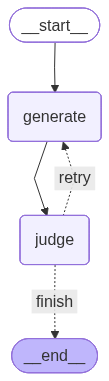

In [38]:
agent_app

In [45]:
user_query = "Наступило утро!"
result = run_agent_langgraph(user_query, max_iters=10, min_score=9)

print("BEST SCORE:", result["best_score"])
print("BEST JUDGE:\n", result["best_judge"])
print("\nFINAL TEXT:\n", result["best_text"])


BEST SCORE: 8
BEST JUDGE:
 Ты — литературный критик и редактор.

Оцени текст по шкале 1..10 по критериям:
1) Соответствие запросу
2) Стиль русской классики
3) Адекватность и логика речи
4) Связность и отсутствие резких сюжетных скачков

Ответь строго в формате:
Score: <число>
Reason: <краткое пояснение>

Запрос:
Наступило утро!

Текст:
Я поднялся и взглянул на солнце. Солнце уже не скрывалось за вершинами гор, а светилось в полной высоте. Я остановился и смотрел, как оно светит на весь мир. Потом медленно и осторожно вышел на крыльцо. На небе было уже светло, но еще было темно на земле: низины еще лежали в тени гор. Воздух был холодный, свежий, но он был пропитан сладким запахом сухих трав. Среди пеньков, по-прежнему раскинувших свои кривые ветви над поляной, стоял синий шар, и оттуда доносился легкий ветерок. Я опустился на корточки, прислонился головой к стволу дерева и стал смотреть на солнце. Солнце медленно поднималось. Оно не двигалось ни вверх, ни вниз, ни влево, ни вправо, а то

In [46]:
result

{'user_prompt': 'Наступило утро!',
 'attempt': 10,
 'max_iters': 10,
 'min_score': 9,
 'candidate_text': 'Я поднялся и взглянул на солнце. Солнце уже не скрывалось за вершинами гор, а светилось в полной высоте. Я остановился и смотрел, как оно светит на весь мир. Потом медленно и осторожно вышел на крыльцо. На небе было уже светло, но еще было темно на земле: низины еще лежали в тени гор. Воздух был холодный, свежий, но он был пропитан сладким запахом сухих трав. Среди пеньков, по-прежнему раскинувших свои кривые ветви над поляной, стоял синий шар, и оттуда доносился легкий ветерок. Я опустился на корточки, прислонился головой к стволу дерева и стал смотреть на солнце. Солнце медленно поднималось. Оно не двигалось ни вверх, ни вниз, ни влево, ни вправо, а только росло и росло; и когда его центральный круг достиг полной высоты, его золотистый огонь осветил все вокруг. Солнце начало двигаться',
 'judge_text': 'Ты — литературный критик и редактор.\n\nОцени текст по шкале 1..10 по критерия

In [50]:
import pandas as pd
import re
import html
from IPython.display import HTML, display

# result = run_ruslit_graph(...) или run_agent_langgraph(...)
hist = result.get("history", [])
df = pd.DataFrame(hist)

def extract_reason(judge_text: str) -> str:
    if not judge_text:
        return ""
    m = re.search(r"Reason:\s*(.*)", str(judge_text), flags=re.DOTALL)
    return m.group(1).strip() if m else ""

def esc(x) -> str:
    return html.escape("" if x is None else str(x))

df["text_full"] = df.get("text", "")
df["judge_full"] = df.get("judge", "")
df["reason_full"] = df["judge_full"].apply(extract_reason)

out = df[["attempt", "score", "text_full", "reason_full", "judge_full"]].sort_values("attempt")

css = """
<style>
table.agent {border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 13px;}
table.agent th, table.agent td {border: 1px solid #ddd; padding: 8px; vertical-align: top;}
table.agent th {background: #f6f6f6; position: sticky; top: 0; z-index: 1;}
.cell-scroll {max-height: 320px; overflow: auto; white-space: pre-wrap; line-height: 1.35;}
.small {width: 70px; white-space: nowrap;}
</style>
"""

rows = []
for _, r in out.iterrows():
    rows.append(f"""
    <tr>
      <td class="small">{int(r['attempt'])}</td>
      <td class="small">{int(r['score'])}</td>
      <td><div class="cell-scroll">{esc(r['text_full'])}</div></td>
      <td><div class="cell-scroll">{esc(r['reason_full'])}</div></td>
      <td><div class="cell-scroll">{esc(r['judge_full'])}</div></td>
    </tr>
    """)

html_table = css + f"""
<table class="agent">
  <thead>
    <tr>
      <th class="small">Attempt</th>
      <th class="small">Score</th>
      <th>Text (full)</th>
      <th>Reason (full)</th>
      <th>Judge output (full)</th>
    </tr>
  </thead>
  <tbody>
    {''.join(rows)}
  </tbody>
</table>
"""

display(HTML(html_table))


Attempt,Score,Text (full),Reason (full),Judge output (full)
1,5,"Светлого, теплого дня! Нет ничего прекраснее, чем утро. Но вчера вечером я был не в силах уснуть, потому что думал о тебе... Я думал о том, как ты меня любишь и как мне хорошо быть с тобой. Вдруг ты стала близко, в моей комнате, на моем ковре, я видел твои глаза, слышал твой голос, чувствовал запах твоих волос... И вот утро: мы расстаемся навсегда. Утро - и несчастье, и горечь. Но есть вещи прекраснее, чем утро. Свяжем наши сердца. Вот наш последний поцелуй... Мы отойдем друг от друга. Но ты будешь жить во мне, и я буду жить в тебе. Мы оба умрем... Всё кончено. Что было, то прошло. Ты убила меня своим приходом и своей красотою. Я умер от любви. Поклонение... (Помолчание). Ты ушла... Тебя больше нет... Но я не могу перестать жить. Я не могу перестать думать о тебе. Я хочу, чтобы ты была здесь...","<краткое пояснение> Запрос: Наступило утро! Текст: Светлого, теплого дня! Нет ничего прекраснее, чем утро. Но вчера вечером я был не в силах уснуть, потому что думал о тебе... Я думал о том, как ты меня любишь и как мне хорошо быть с тобой. Вдруг ты стала близко, в моей комнате, на моем ковре, я видел твои глаза, слышал твой голос, чувствовал запах твоих волос... И вот утро: мы расстаемся навсегда. Утро - и несчастье, и горечь. Но есть вещи прекраснее, чем утро. Свяжем наши сердца. Вот наш последний поцелуй... Мы отойдем друг от друга. Но ты будешь жить во мне, и я буду жить в тебе. Мы оба умрем... Всё кончено. Что было, то прошло. Ты убила меня своим приходом и своей красотою. Я умер от любви. Поклонение... (Помолчание). Ты ушла... Тебя больше нет... Но я не могу перестать жить. Я не могу перестать думать о тебе. Я хочу, чтобы ты была здесь... Score: 5 Reason: Текст не соответствует запросу, поскольку не описывает утро в прямом смысле слова, а содержит эмоциональные монологи о расставании. Стиль не соответствует стилю русской классики, а слишком современен и эмоционален. Адекватность и логика речи хорошие, но связность и отсутствие резких сюжетных скачков отсутствуют из-за неожиданного перехода от утра к эмоциональному монологу.","Ты — литературный критик и редактор. Оцени текст по шкале 1..10 по критериям: 1) Соответствие запросу 2) Стиль русской классики 3) Адекватность и логика речи 4) Связность и отсутствие резких сюжетных скачков Ответь строго в формате: Score: <число> Reason: <краткое пояснение> Запрос: Наступило утро! Текст: Светлого, теплого дня! Нет ничего прекраснее, чем утро. Но вчера вечером я был не в силах уснуть, потому что думал о тебе... Я думал о том, как ты меня любишь и как мне хорошо быть с тобой. Вдруг ты стала близко, в моей комнате, на моем ковре, я видел твои глаза, слышал твой голос, чувствовал запах твоих волос... И вот утро: мы расстаемся навсегда. Утро - и несчастье, и горечь. Но есть вещи прекраснее, чем утро. Свяжем наши сердца. Вот наш последний поцелуй... Мы отойдем друг от друга. Но ты будешь жить во мне, и я буду жить в тебе. Мы оба умрем... Всё кончено. Что было, то прошло. Ты убила меня своим приходом и своей красотою. Я умер от любви. Поклонение... (Помолчание). Ты ушла... Тебя больше нет... Но я не могу перестать жить. Я не могу перестать думать о тебе. Я хочу, чтобы ты была здесь... Score: 5 Reason: Текст не соответствует запросу, поскольку не описывает утро в прямом смысле слова, а содержит эмоциональные монологи о расставании. Стиль не соответствует стилю русской классики, а слишком современен и эмоционален. Адекватность и логика речи хорошие, но связность и отсутствие резких сюжетных скачков отсутствуют из-за неожиданного перехода от утра к эмоциональному монологу."
2,6,"Во дворе разгуливали котята. Коты не шли: только мурлыкали и зевали. В кухне гремели тарелки. Дверь в комнатах была отворена. Сидевшие на стульях, одетые в старые, грязные платья, читали, дремали или разговаривали тихо. Из открытого окна доносился звонкий смех детей. Тут же, за столом, сидела девочка, сестра Ольги, и, как и она, не хотела вставать. Она тоже лен

Драма-квин он еще тот!:)

# Вывод

Реализован простой агент на LangGraph с циклом Generate → Judge → Retry/Finish.

- Состояние (AgentState) хранит текущую попытку, последний сгенерированный текст, оценку судьи, а также лучший найденный вариант и историю попыток.

- На каждом шаге узел generate вызывает инструмент генерации (модель с LoRA-адаптером RusLit), после чего узел judge оценивает качество через отдельный инструмент-судью (базовая модель без адаптера) и обновляет best_* и history.

- Маршрутизация route_after_judge завершает процесс при достижении порога качества (score >= min_score) или по лимиту итераций (max_iters, максимум 3), иначе выполняется повторная генерация.

- Такой агент обеспечивает автоматический контроль качества и повышает вероятность получить подходящий текст без ручного перебора, при этом число перегенераций и стоимость вычислений остаются ограниченными.